# Graph Neural Network for US Corporate Bond Pricing

## A Prototype Model Using Synthetic TRACE-like Data

---

### Overview

This notebook implements a Graph Neural Network (GNN) for pricing US corporate bonds using synthetic data
modeled after FINRA's TRACE (Trade Reporting and Compliance Engine) feed. The key insight is that bonds
with similar characteristics should trade at similar spread levels, and information propagates through
a network of related bonds — a structure naturally captured by GNNs.

**Why GNNs for bond pricing?** Corporate bonds trade infrequently and OTC, creating severe data sparsity.
For any given bond, there may be no recent trade. But similar bonds *do* trade, and a GNN can propagate
pricing information from recently-traded neighbors to stale bonds through learned message-passing.

### Table of Contents

1. [Assumptions, Strengths & Weaknesses](#section-1)
2. [Synthetic Data Generation](#section-2)
3. [Graph Construction](#section-3)
4. [GNN Model Architecture](#section-4)
5. [Training & Validation](#section-5)
6. [Results & Diagnostics](#section-6)
7. [Future Research Directions](#section-7)

<a id='section-1'></a>
## 1. Assumptions, Strengths & Weaknesses

### Assumptions

- **Spread-to-benchmark** is the appropriate pricing representation (abstracts away rate risk, focuses on credit).
- **Bond similarity** in characteristic space is a meaningful proxy for spread co-movement.
- **Stationarity within training window**: the relationship between bond features and spreads is locally stationary.
- **Graph topology is relatively stable**: edges (similarity relationships) don't change drastically tick-to-tick.
- **Synthetic data**: the Ornstein-Uhlenbeck spread process with sector/rating-driven mean levels is a reasonable
  first-order approximation of real spread dynamics.
- **No dealer/venue effects**: we ignore the identity of reporting dealers, trade size tiers, and inter-dealer
  vs. dealer-to-client distinctions that heavily influence TRACE reported levels.

### Strengths

- **Handles irregular time spacing**: node features encode time-since-last-trade, so the model learns
  staleness-aware pricing.
- **Propagates information across the credit network**: a BBB Industrial bond with no recent trade borrows
  signal from recently-traded BBB Industrial neighbors.
- **Flexible feature engineering**: any bond-level or market-level feature can be appended to node feature vectors.
- **Non-linear spread surface**: unlike matrix pricing or linear models, the GNN can learn complex
  interactions (e.g., rating × sector × maturity interactions).
- **Scalable**: message-passing GNNs are O(|E|) per layer, efficient even for large bond universes.

### Weaknesses

- **Graph construction is a hyperparameter**: k-NN threshold and distance metric choice heavily
  influence model quality. There is no single "correct" graph.
- **Static graph**: real-world bond similarity evolves (e.g., a bond approaching maturity moves
  closer to shorter-dated peers). This prototype uses a fixed graph.
- **No temporal graph dynamics**: we snapshot features at each timestamp but don't model the
  sequential evolution of the graph state (cf. temporal GNNs, EvolveGCN).
- **Synthetic data bias**: the data-generating process may be too "clean" — real TRACE data has
  reporting errors, cancellations, delayed prints, and agency vs. principal markups.
- **Overfitting risk on small universes**: with few hundred bonds, the GNN may memorize rather
  than generalize, especially with deep architectures.
- **No uncertainty quantification**: point estimates only; no prediction intervals or
  distributional output (see future work).
- **No liquidity modeling**: trade frequency and bid-ask bounce are not modeled explicitly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.spatial.distance import pdist, squareform

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


<a id='section-2'></a>
## 2. Synthetic Data Generation

We generate a realistic universe of ~400 US corporate bonds with characteristics drawn from
empirical distributions. Spreads follow an Ornstein-Uhlenbeck process:

$$dS_t = \kappa(\mu - S_t)dt + \sigma dW_t$$

where the long-run mean $\mu$ is determined by the bond's rating, sector, and maturity.
Trades arrive as a Poisson process with intensity varying by liquidity tier.

In [2]:
# === Bond Universe Parameters ===
N_BONDS = 400
N_ISSUERS = 120
HISTORY_DAYS = 180

# Rating categories and their base spread levels (bps, converted to pct below)
RATINGS = ['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-',
           'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-', 'B+', 'B', 'B-']
RATING_WEIGHTS = [0.01, 0.02, 0.04, 0.05, 0.08, 0.12, 0.10,
                  0.12, 0.12, 0.08, 0.06, 0.05, 0.04, 0.04, 0.04, 0.03]
RATING_BASE_SPREAD = {
    'AAA': 0.30, 'AA+': 0.40, 'AA': 0.50, 'AA-': 0.60,
    'A+': 0.75, 'A': 0.90, 'A-': 1.10,
    'BBB+': 1.35, 'BBB': 1.60, 'BBB-': 2.00,
    'BB+': 2.60, 'BB': 3.20, 'BB-': 3.90,
    'B+': 4.80, 'B': 5.80, 'B-': 7.00
}  # in percent

SECTORS = ['Financials', 'Industrials', 'Technology', 'Healthcare',
           'Energy', 'Utilities', 'Consumer', 'Telecom', 'Materials', 'Real Estate']
SECTOR_WEIGHTS = [0.20, 0.15, 0.12, 0.10, 0.10, 0.08, 0.08, 0.06, 0.06, 0.05]
SECTOR_SPREAD_ADJ = {
    'Financials': -0.05, 'Industrials': 0.0, 'Technology': -0.08,
    'Healthcare': 0.02, 'Energy': 0.15, 'Utilities': -0.10,
    'Consumer': 0.0, 'Telecom': 0.05, 'Materials': 0.10, 'Real Estate': 0.08
}

# Maturity term structure slope (spread widens with maturity)
def maturity_adj(ytm):
    """Spread adjustment for years-to-maturity (log-concave shape)."""
    return 0.12 * np.log1p(ytm / 5.0)

print(f'Generating universe of {N_BONDS} bonds across {N_ISSUERS} issuers...')

Generating universe of 400 bonds across 120 issuers...


In [3]:
# === Generate Bond Reference Data ===
rng = np.random.default_rng(42)

# Assign issuers to sectors
issuer_ids = [f'ISSUER_{i:04d}' for i in range(N_ISSUERS)]
issuer_sectors = rng.choice(SECTORS, size=N_ISSUERS, p=SECTOR_WEIGHTS)
issuer_sector_map = dict(zip(issuer_ids, issuer_sectors))

# Generate bonds
bonds = []
for i in range(N_BONDS):
    cusip = f'{rng.integers(100000000, 999999999)}'
    issuer = rng.choice(issuer_ids)
    sector = issuer_sector_map[issuer]
    rating = rng.choice(RATINGS, p=RATING_WEIGHTS)

    # Years to maturity: mixture of short (1-3y), medium (3-10y), long (10-30y)
    mat_bucket = rng.choice(['short', 'medium', 'long'], p=[0.25, 0.45, 0.30])
    if mat_bucket == 'short':
        ytm = rng.uniform(0.5, 3.0)
    elif mat_bucket == 'medium':
        ytm = rng.uniform(3.0, 10.0)
    else:
        ytm = rng.uniform(10.0, 30.0)

    coupon = np.round(rng.uniform(1.5, 8.5), 3)
    # Higher-rated issuers tend to have lower coupons
    rating_idx = RATINGS.index(rating)
    coupon = np.round(coupon + rating_idx * 0.15, 3)

    amount_outstanding = rng.choice([250, 500, 750, 1000, 1250, 1500, 2000, 2500, 3000],
                                     p=[0.05, 0.15, 0.15, 0.20, 0.15, 0.10, 0.10, 0.05, 0.05])

    is_144a = rng.random() < 0.25  # ~25% are 144A
    is_regS = rng.random() < 0.10 if is_144a else rng.random() < 0.05
    is_callable = rng.random() < 0.60  # ~60% callable
    is_make_whole = is_callable and (rng.random() < 0.70)  # most callables are make-whole
    is_subordinated = rng.random() < 0.08
    is_secured = rng.random() < 0.05

    # Seniority affects spread
    seniority = 'Subordinated' if is_subordinated else ('Secured' if is_secured else 'Senior Unsecured')

    bonds.append({
        'cusip': cusip,
        'issuer': issuer,
        'sector': sector,
        'rating': rating,
        'rating_numeric': rating_idx,
        'coupon': coupon,
        'years_to_maturity': np.round(ytm, 2),
        'amount_outstanding_mm': amount_outstanding,
        'is_144a': int(is_144a),
        'is_regS': int(is_regS),
        'is_callable': int(is_callable),
        'is_make_whole': int(is_make_whole),
        'seniority': seniority,
        'is_subordinated': int(is_subordinated),
        'is_secured': int(is_secured),
    })

bond_ref = pd.DataFrame(bonds)
print(f'Bond universe: {len(bond_ref)} bonds, {bond_ref.issuer.nunique()} issuers')
print(f'\nRating distribution:')
print(bond_ref.rating.value_counts().sort_index())
print(f'\nSector distribution:')
print(bond_ref.sector.value_counts())

Bond universe: 400 bonds, 119 issuers

Rating distribution:
rating
A       41
A+      38
A-      41
AA      24
AA+     10
AA-     28
AAA      2
B       14
B+      18
B-      14
BB      17
BB+     23
BB-     14
BBB     45
BBB+    46
BBB-    25
Name: count, dtype: int64

Sector distribution:
sector
Technology     79
Financials     72
Consumer       48
Energy         46
Industrials    45
Healthcare     37
Utilities      27
Real Estate    21
Telecom        13
Materials      12
Name: count, dtype: int64


In [4]:
# === Generate Trading History via Ornstein-Uhlenbeck Process ===

def generate_ou_trades(bond_row, n_days=HISTORY_DAYS, dt=1/252):
    """
    Simulate an OU spread process and sample trades at Poisson arrival times.
    Returns a DataFrame of trades for one bond.
    """
    rating = bond_row['rating']
    sector = bond_row['sector']
    ytm = bond_row['years_to_maturity']
    is_sub = bond_row['is_subordinated']
    is_144a = bond_row['is_144a']

    # Mean-reversion target
    mu = (RATING_BASE_SPREAD[rating]
          + SECTOR_SPREAD_ADJ[sector]
          + maturity_adj(ytm)
          + 0.40 * is_sub       # subordination premium
          + 0.08 * is_144a)     # small 144A illiquidity premium
    mu = max(mu, 0.05)  # floor

    # OU parameters (rating-dependent volatility)
    rating_idx = RATINGS.index(rating)
    kappa = 0.05 + 0.01 * rating_idx  # faster mean-reversion for HY
    sigma = 0.02 + 0.015 * rating_idx  # more vol for HY

    # Trade arrival intensity (trades/day) — more liquid for IG benchmark issues
    base_intensity = 2.0 if rating_idx < 10 else 0.8  # IG vs HY
    amt_factor = bond_row['amount_outstanding_mm'] / 1000.0
    intensity = base_intensity * (0.5 + 0.5 * amt_factor)

    # Simulate OU path at daily granularity
    n_steps = n_days
    spread_path = np.zeros(n_steps)
    spread_path[0] = mu + rng.normal(0, sigma * 2)  # initial around mean

    for t in range(1, n_steps):
        dW = rng.normal(0, np.sqrt(dt))
        spread_path[t] = (spread_path[t-1]
                          + kappa * (mu - spread_path[t-1]) * dt
                          + sigma * dW)
        spread_path[t] = max(spread_path[t], 0.01)  # floor at 1bp

    # Sample trade times (Poisson process)
    trades = []
    base_date = datetime(2025, 6, 1)
    for day in range(n_steps):
        n_trades_today = rng.poisson(intensity * dt * 252)  # expected trades/day
        for _ in range(n_trades_today):
            hour = rng.integers(8, 17)  # trading hours
            minute = rng.integers(0, 60)
            second = rng.integers(0, 60)
            ts = base_date + timedelta(days=int(day), hours=int(hour),
                                       minutes=int(minute), seconds=int(second))
            # Add trade-level noise (bid-ask bounce, size impact)
            trade_noise = rng.normal(0, 0.03 + 0.01 * rating_idx)
            trade_spread = np.round(spread_path[day] + trade_noise, 4)
            trade_spread = max(trade_spread, 0.005)

            # Trade size
            size_mm = rng.choice([0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0],
                                 p=[0.15, 0.20, 0.25, 0.20, 0.10, 0.07, 0.03])

            trades.append({
                'cusip': bond_row['cusip'],
                'timestamp': ts,
                'spread_pct': trade_spread,
                'trade_size_mm': size_mm,
            })

    return pd.DataFrame(trades)

# Generate trades for all bonds
print('Generating trade history...')
all_trades = []
for idx, row in bond_ref.iterrows():
    trades_df = generate_ou_trades(row)
    all_trades.append(trades_df)

trades = pd.concat(all_trades, ignore_index=True)
trades = trades.sort_values('timestamp').reset_index(drop=True)

print(f'Total trades generated: {len(trades):,}')
print(f'Date range: {trades.timestamp.min()} to {trades.timestamp.max()}')
print(f'Avg trades per bond: {len(trades) / N_BONDS:.1f}')
print(f'\nSpread summary (pct):')
print(trades.spread_pct.describe())

Generating trade history...
Total trades generated: 136,556
Date range: 2025-06-01 08:00:34 to 2025-11-27 16:59:36
Avg trades per bond: 341.4

Spread summary (pct):
count    136556.000000
mean          1.649720
std           1.249282
min           0.212100
25%           0.894800
50%           1.314600
75%           1.883100
max           7.964000
Name: spread_pct, dtype: float64


In [5]:
# === Merge & Create the Full Dataset ===
dataset = trades.merge(bond_ref, on='cusip', how='left')

# Add time-since-last-trade per bond (critical feature for staleness)
dataset = dataset.sort_values(['cusip', 'timestamp']).reset_index(drop=True)
dataset['prev_trade_time'] = dataset.groupby('cusip')['timestamp'].shift(1)
dataset['hours_since_last_trade'] = (
    (dataset['timestamp'] - dataset['prev_trade_time']).dt.total_seconds() / 3600
).fillna(0)

# Previous spread (for momentum / mean-reversion features)
dataset['prev_spread'] = dataset.groupby('cusip')['spread_pct'].shift(1)
dataset['spread_change'] = dataset['spread_pct'] - dataset['prev_spread']
dataset = dataset.dropna(subset=['prev_spread']).reset_index(drop=True)

print(f'Final dataset shape: {dataset.shape}')
print(f'\nSample records:')
dataset[['cusip', 'timestamp', 'spread_pct', 'rating', 'sector',
         'coupon', 'years_to_maturity', 'hours_since_last_trade']].head(10)

Final dataset shape: (136156, 22)

Sample records:


,cusip,timestamp,spread_pct,rating,sector,coupon,years_to_maturity,hours_since_last_trade
0,102011684,2025-06-03 12:43:32,5.4539,B+,Telecom,7.481,17.44,0.965000
1,102011684,2025-06-04 12:57:07,5.3900,B+,Telecom,7.481,17.44,24.226389
2,102011684,2025-06-05 15:23:52,5.4658,B+,Telecom,7.481,17.44,26.445833
3,102011684,2025-06-08 08:33:31,5.4086,B+,Telecom,7.481,17.44,65.160833
4,102011684,2025-06-09 08:08:54,5.4125,B+,Telecom,7.481,17.44,23.589722
5,102011684,2025-06-09 14:39:05,5.3670,B+,Telecom,7.481,17.44,6.503056
6,102011684,2025-06-10 14:40:31,5.0031,B+,Telecom,7.481,17.44,24.023889
7,102011684,2025-06-12 10:36:33,5.2835,B+,Telecom,7.481,17.44,43.933889
8,102011684,2025-06-15 10:10:11,5.0736,B+,Telecom,7.481,17.44,71.560556
9,102011684,2025-06-16 10:45:23,5.1850,B+,Telecom,7.481,17.44,24.586667


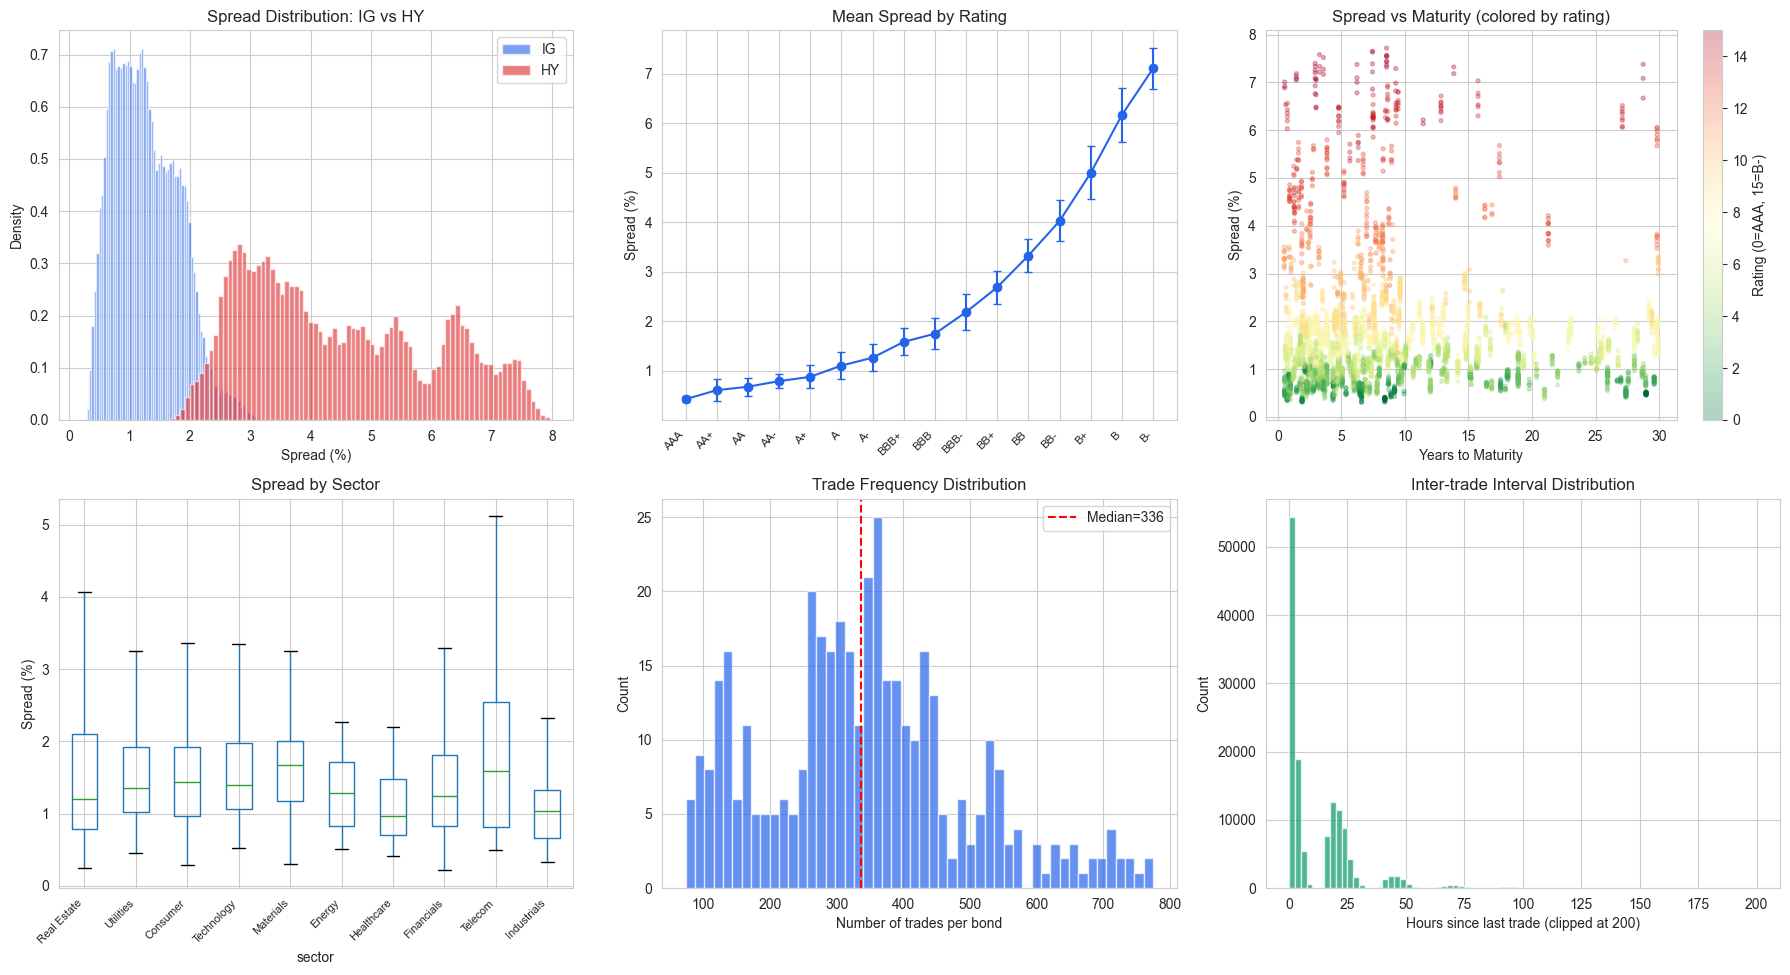

In [6]:
# === Visualize the Synthetic Data ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Spread distribution by rating bucket
ig_mask = dataset['rating_numeric'] < 10
ax = axes[0, 0]
for label, mask, color in [('IG', ig_mask, '#2563eb'), ('HY', ~ig_mask, '#dc2626')]:
    ax.hist(dataset.loc[mask, 'spread_pct'], bins=80, alpha=0.6, label=label, color=color, density=True)
ax.set_xlabel('Spread (%)')
ax.set_ylabel('Density')
ax.set_title('Spread Distribution: IG vs HY')
ax.legend()

# 2. Spread vs Rating
ax = axes[0, 1]
rating_means = dataset.groupby('rating_numeric')['spread_pct'].agg(['mean', 'std']).reset_index()
ax.errorbar(rating_means['rating_numeric'], rating_means['mean'],
            yerr=rating_means['std'], fmt='o-', capsize=3, color='#2563eb')
ax.set_xticks(range(len(RATINGS)))
ax.set_xticklabels(RATINGS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Spread (%)')
ax.set_title('Mean Spread by Rating')

# 3. Spread vs Maturity
ax = axes[0, 2]
sample = dataset.sample(min(5000, len(dataset)), random_state=42)
scatter = ax.scatter(sample['years_to_maturity'], sample['spread_pct'],
                     c=sample['rating_numeric'], cmap='RdYlGn_r', alpha=0.3, s=8)
plt.colorbar(scatter, ax=ax, label='Rating (0=AAA, 15=B-)')
ax.set_xlabel('Years to Maturity')
ax.set_ylabel('Spread (%)')
ax.set_title('Spread vs Maturity (colored by rating)')

# 4. Sector spread box plot
ax = axes[1, 0]
sector_order = dataset.groupby('sector')['spread_pct'].median().sort_values().index
dataset.boxplot(column='spread_pct', by='sector', ax=ax,
                positions=range(len(sector_order)),
                showfliers=False)
ax.set_xticklabels(sector_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Spread (%)')
ax.set_title('Spread by Sector')
plt.suptitle('')  # remove auto-title from boxplot

# 5. Trade frequency distribution
ax = axes[1, 1]
trade_counts = dataset.groupby('cusip').size()
ax.hist(trade_counts, bins=50, color='#2563eb', alpha=0.7, edgecolor='white')
ax.set_xlabel('Number of trades per bond')
ax.set_ylabel('Count')
ax.set_title('Trade Frequency Distribution')
ax.axvline(trade_counts.median(), color='red', linestyle='--', label=f'Median={trade_counts.median():.0f}')
ax.legend()

# 6. Time-since-last-trade distribution
ax = axes[1, 2]
ax.hist(dataset['hours_since_last_trade'].clip(upper=200), bins=80,
        color='#059669', alpha=0.7, edgecolor='white')
ax.set_xlabel('Hours since last trade (clipped at 200)')
ax.set_ylabel('Count')
ax.set_title('Inter-trade Interval Distribution')

plt.tight_layout()
plt.show()

<a id='section-3'></a>
## 3. Graph Construction

We construct the bond similarity graph using **k-Nearest Neighbors** in a Gower-like mixed
feature space (continuous + categorical). Each bond is a node; edges connect bonds that are
"similar" based on their static characteristics.

**Why k-NN over other clustering methods?**
- k-NN produces a **fixed-degree sparse graph**, which is computationally efficient and avoids
  the density-based issues of DBSCAN/HDBSCAN (which would partition bonds into clusters rather
  than building a neighborhood graph).
- The resulting graph is naturally suited for GNN message-passing: each bond aggregates
  information from its k most similar peers.
- k is a clean hyperparameter with intuitive meaning ("each bond looks at its k closest comps").

In [7]:
# === Build Feature Matrix for Graph Construction ===
# We use bond-level static features to define similarity

# Encode categoricals
le_sector = LabelEncoder()
bond_ref['sector_enc'] = le_sector.fit_transform(bond_ref['sector'])

le_seniority = LabelEncoder()
bond_ref['seniority_enc'] = le_seniority.fit_transform(bond_ref['seniority'])

# Feature matrix for graph construction
graph_features = bond_ref[[
    'rating_numeric',
    'sector_enc',
    'coupon',
    'years_to_maturity',
    'amount_outstanding_mm',
    'is_144a',
    'is_callable',
    'is_subordinated',
    'seniority_enc',
]].copy()

# Normalize for distance computation
scaler_graph = StandardScaler()
graph_features_scaled = scaler_graph.fit_transform(graph_features)

# Apply feature importance weights
# Rating and sector matter most for credit spread similarity
feature_weights = np.array([3.0,   # rating (most important)
                            2.0,   # sector
                            0.5,   # coupon
                            1.5,   # maturity
                            0.3,   # amount outstanding
                            0.8,   # 144a
                            0.5,   # callable
                            1.0,   # subordinated
                            1.0])  # seniority

graph_features_weighted = graph_features_scaled * feature_weights[np.newaxis, :]

print(f'Graph feature matrix shape: {graph_features_weighted.shape}')

Graph feature matrix shape: (400, 9)


In [8]:
# === Build k-NN Graph ===
K_NEIGHBORS = 10  # each bond connects to its 10 most similar peers

nn_model = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='euclidean')  # +1 for self
nn_model.fit(graph_features_weighted)
distances, indices = nn_model.kneighbors(graph_features_weighted)

# Build edge index (COO format, removing self-loops)
edge_src = []
edge_dst = []
edge_weight = []

for i in range(N_BONDS):
    for j_idx in range(1, K_NEIGHBORS + 1):  # skip self at index 0
        neighbor = indices[i, j_idx]
        dist = distances[i, j_idx]
        # Gaussian kernel weight
        w = np.exp(-dist**2 / (2 * np.median(distances[:, 1:])**2))
        edge_src.append(i)
        edge_dst.append(neighbor)
        edge_weight.append(w)

# Make undirected by adding reverse edges
edge_src_full = edge_src + edge_dst
edge_dst_full = edge_dst + edge_src
edge_weight_full = edge_weight + edge_weight

# Remove duplicates
edge_set = set()
unique_src, unique_dst, unique_w = [], [], []
for s, d, w in zip(edge_src_full, edge_dst_full, edge_weight_full):
    if (s, d) not in edge_set:
        edge_set.add((s, d))
        unique_src.append(s)
        unique_dst.append(d)
        unique_w.append(w)

edge_index = torch.tensor([unique_src, unique_dst], dtype=torch.long)
edge_weights = torch.tensor(unique_w, dtype=torch.float32)

print(f'Graph: {N_BONDS} nodes, {edge_index.shape[1]} edges')
print(f'Avg degree: {edge_index.shape[1] / N_BONDS:.1f}')
print(f'Edge weight range: [{edge_weights.min():.4f}, {edge_weights.max():.4f}]')

Graph: 400 nodes, 5158 edges
Avg degree: 12.9
Edge weight range: [0.0080, 0.9965]


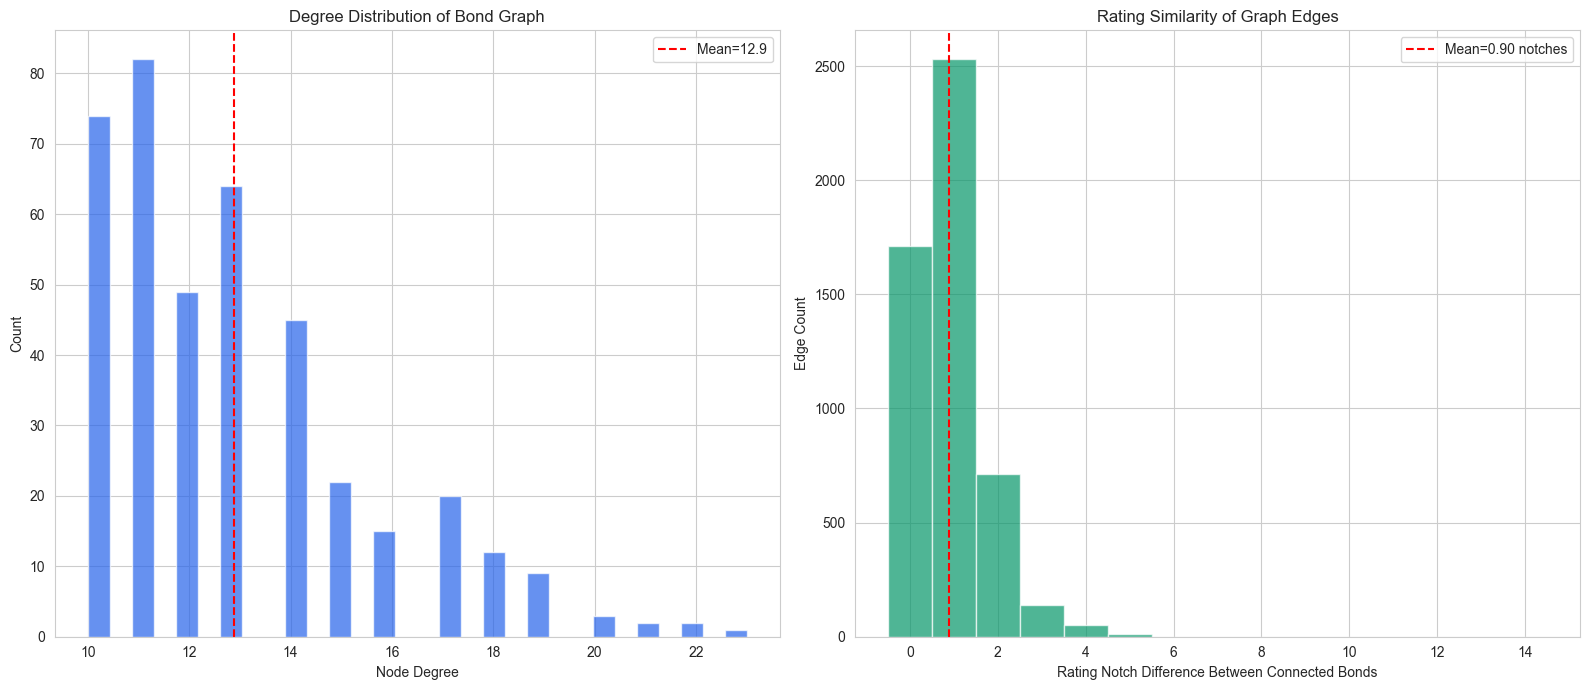


Edge quality check:
  96.1% of edges connect bonds within 2 rating notches
  38.1% of edges connect bonds in the same sector


In [9]:
# === Visualize the Graph (subset) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Degree distribution
ax = axes[0]
degrees = np.bincount(edge_index[0].numpy(), minlength=N_BONDS)
ax.hist(degrees, bins=30, color='#2563eb', alpha=0.7, edgecolor='white')
ax.set_xlabel('Node Degree')
ax.set_ylabel('Count')
ax.set_title('Degree Distribution of Bond Graph')
ax.axvline(np.mean(degrees), color='red', linestyle='--', label=f'Mean={np.mean(degrees):.1f}')
ax.legend()

# Neighbor similarity: do connected bonds have similar ratings?
ax = axes[1]
src_ratings = bond_ref['rating_numeric'].values[edge_index[0].numpy()]
dst_ratings = bond_ref['rating_numeric'].values[edge_index[1].numpy()]
rating_diffs = np.abs(src_ratings - dst_ratings)
ax.hist(rating_diffs, bins=range(0, 16), color='#059669', alpha=0.7, edgecolor='white', align='left')
ax.set_xlabel('Rating Notch Difference Between Connected Bonds')
ax.set_ylabel('Edge Count')
ax.set_title('Rating Similarity of Graph Edges')
ax.axvline(np.mean(rating_diffs), color='red', linestyle='--',
           label=f'Mean={np.mean(rating_diffs):.2f} notches')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\nEdge quality check:')
print(f'  {(rating_diffs <= 2).mean()*100:.1f}% of edges connect bonds within 2 rating notches')
same_sector = (bond_ref['sector_enc'].values[edge_index[0].numpy()]
               == bond_ref['sector_enc'].values[edge_index[1].numpy()])
print(f'  {same_sector.mean()*100:.1f}% of edges connect bonds in the same sector')

<a id='section-4'></a>
## 4. GNN Model Architecture

We implement a **Graph Convolutional Network (GCN)** with the following design choices:

- **2 GCN layers** with residual connections for message-passing
- **Edge-weight-aware aggregation**: neighbors contribute proportional to their similarity weight
- **LayerNorm** instead of BatchNorm (more stable for graph data with variable neighborhoods)
- **MLP head** for final spread prediction from the learned node embeddings
- **Ablation baseline**: a pure MLP with identical input features (no graph structure)

### Message-Passing Update Rule

For node $i$ at layer $l$:

$$h_i^{(l+1)} = \sigma\left(W^{(l)} \cdot \left( h_i^{(l)} + \sum_{j \in \mathcal{N}(i)} \frac{w_{ij}}{\sqrt{d_i d_j}} h_j^{(l)} \right)\right)$$

where $w_{ij}$ is the edge weight and $d_i = \sum_j w_{ij}$ is the weighted degree.

In [10]:
# === Prepare Node Features for Training ===
# For each trade event, we create a "snapshot" of the graph with current node features.
# Since full-graph snapshots per trade are expensive, we batch by day.

# Encode features
le_sector_full = LabelEncoder()
dataset['sector_enc'] = le_sector_full.fit_transform(dataset['sector'])

le_seniority_full = LabelEncoder()
dataset['seniority_enc'] = le_seniority_full.fit_transform(dataset['seniority'])

# Build cusip-to-index mapping
cusip_to_idx = {c: i for i, c in enumerate(bond_ref['cusip'].values)}
dataset['bond_idx'] = dataset['cusip'].map(cusip_to_idx)

# Node feature columns (per trade)
NODE_FEATURES = [
    'rating_numeric',
    'coupon',
    'years_to_maturity',
    'amount_outstanding_mm',
    'is_144a',
    'is_regS',
    'is_callable',
    'is_make_whole',
    'is_subordinated',
    'is_secured',
    'sector_enc',
    'seniority_enc',
    'hours_since_last_trade',
    'prev_spread',
    'trade_size_mm',
]

# Normalize features
scaler_node = StandardScaler()
dataset[NODE_FEATURES] = scaler_node.fit_transform(dataset[NODE_FEATURES])

# Target: spread_pct (we keep it in original scale)
TARGET = 'spread_pct'

N_FEATURES = len(NODE_FEATURES)
print(f'Node feature dimension: {N_FEATURES}')
print(f'Features: {NODE_FEATURES}')

Node feature dimension: 15
Features: ['rating_numeric', 'coupon', 'years_to_maturity', 'amount_outstanding_mm', 'is_144a', 'is_regS', 'is_callable', 'is_make_whole', 'is_subordinated', 'is_secured', 'sector_enc', 'seniority_enc', 'hours_since_last_trade', 'prev_spread', 'trade_size_mm']


In [11]:
# === Create Training Samples ===
# Each sample: (node_features_for_all_bonds, target_spread, bond_index)
# We aggregate to daily snapshots for efficiency.

dataset['trade_date'] = dataset['timestamp'].dt.date

# For each day, take the last trade per bond as the "closing" observation
daily = (dataset
         .sort_values('timestamp')
         .groupby(['cusip', 'trade_date'])
         .last()
         .reset_index())

print(f'Daily observations: {len(daily):,}')
print(f'Unique dates: {daily.trade_date.nunique()}')

# Build per-trade samples: each row is one training example
# node_features = static bond features + dynamic features (prev_spread, hours_since_last_trade)
X = daily[NODE_FEATURES].values.astype(np.float32)
y = daily[TARGET].values.astype(np.float32)
bond_indices = daily['bond_idx'].values

print(f'X shape: {X.shape}')
print(f'y range: [{y.min():.4f}, {y.max():.4f}]')

Daily observations: 57,105
Unique dates: 180
X shape: (57105, 15)
y range: [0.2497, 7.9640]


In [12]:
# === Train / Validation / Test Split (temporal) ===
# Critical: split by time, not randomly, to avoid look-ahead bias.

dates_sorted = np.sort(daily['trade_date'].unique())
n_dates = len(dates_sorted)
train_cutoff = dates_sorted[int(0.6 * n_dates)]
val_cutoff = dates_sorted[int(0.8 * n_dates)]

train_mask = daily['trade_date'] <= train_cutoff
val_mask = (daily['trade_date'] > train_cutoff) & (daily['trade_date'] <= val_cutoff)
test_mask = daily['trade_date'] > val_cutoff

X_train, y_train, idx_train = X[train_mask], y[train_mask], bond_indices[train_mask]
X_val, y_val, idx_val = X[val_mask], y[val_mask], bond_indices[val_mask]
X_test, y_test, idx_test = X[test_mask], y[test_mask], bond_indices[test_mask]

print(f'Train: {len(X_train):,} samples (up to {train_cutoff})')
print(f'Val:   {len(X_val):,} samples ({train_cutoff} to {val_cutoff})')
print(f'Test:  {len(X_test):,} samples (after {val_cutoff})')

Train: 34,504 samples (up to 2025-09-17)
Val:   11,436 samples (2025-09-17 to 2025-10-23)
Test:  11,165 samples (after 2025-10-23)


In [13]:
# === GCN Layer (from scratch, no PyG dependency) ===

class GCNConv(nn.Module):
    """Graph Convolutional layer with edge-weight support."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x, edge_index, edge_weight=None):
        """
        x: (N, in_channels) node features
        edge_index: (2, E) edge list
        edge_weight: (E,) optional edge weights
        """
        N = x.size(0)
        src, dst = edge_index

        # Compute degree for normalization
        if edge_weight is None:
            edge_weight = torch.ones(src.size(0), device=x.device)

        # D^{-1/2} normalization
        deg = torch.zeros(N, device=x.device)
        deg.scatter_add_(0, dst, edge_weight)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        # Normalize edge weights
        norm = deg_inv_sqrt[src] * edge_weight * deg_inv_sqrt[dst]

        # Message passing: aggregate neighbor features
        # out[dst] += norm * x[src]
        out = torch.zeros_like(x)
        msg = x[src] * norm.unsqueeze(-1)
        out.scatter_add_(0, dst.unsqueeze(-1).expand_as(msg), msg)

        # Add self-loop (identity)
        out = out + x

        # Linear transform
        out = self.linear(out)
        return out


class BondGCN(nn.Module):
    """
    GCN for bond spread prediction.

    Architecture:
      Input -> GCN1 -> LayerNorm -> ReLU -> Dropout
            -> GCN2 -> LayerNorm -> ReLU -> Dropout (+ residual)
            -> MLP Head -> Spread prediction
    """

    def __init__(self, n_features, hidden_dim=64, n_gcn_layers=2, dropout=0.2):
        super().__init__()
        self.n_gcn_layers = n_gcn_layers

        # Input projection
        self.input_proj = nn.Linear(n_features, hidden_dim)

        # GCN layers
        self.gcn_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_gcn_layers):
            self.gcn_layers.append(GCNConv(hidden_dim, hidden_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))

        # MLP head
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_weight=None, node_mask=None):
        """
        x: (N, n_features) — full graph node features
        node_mask: indices of nodes to predict (optional)
        Returns: (|node_mask|, 1) spread predictions
        """
        h = self.input_proj(x)

        for i in range(self.n_gcn_layers):
            h_prev = h
            h = self.gcn_layers[i](h, edge_index, edge_weight)
            h = self.norms[i](h)
            h = F.relu(h)
            h = self.dropout(h)
            h = h + h_prev  # residual

        if node_mask is not None:
            h = h[node_mask]

        return self.head(h).squeeze(-1)


class BondMLP(nn.Module):
    """Baseline MLP (no graph structure) for ablation."""

    def __init__(self, n_features, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index=None, edge_weight=None, node_mask=None):
        if node_mask is not None:
            x = x[node_mask]
        return self.net(x).squeeze(-1)


print('Models defined.')
print(f'GCN parameters: {sum(p.numel() for p in BondGCN(N_FEATURES).parameters()):,}')
print(f'MLP parameters: {sum(p.numel() for p in BondMLP(N_FEATURES).parameters()):,}')

Models defined.
GCN parameters: 11,713
MLP parameters: 7,553


<a id='section-5'></a>
## 5. Training & Validation

We train both the GCN and the MLP baseline using:
- **Huber loss** (robust to spread outliers)
- **AdamW** optimizer with weight decay
- **ReduceLROnPlateau** scheduler
- **Mini-batch over bonds per day**: for each day, we create the full graph snapshot
  and predict spreads only for bonds that traded that day.

For efficiency in this prototype, we use a simplified batching scheme where all
training samples share the same graph topology, and each sample contributes its
own node features at its bond index.

In [14]:
# === Training Infrastructure ===

def create_graph_batch(X_batch, bond_idx_batch, n_nodes, n_features):
    """
    Create a full-graph feature matrix from a batch of individual bond observations.
    Bonds without observations in this batch get zero features (masked).
    """
    node_features = torch.zeros(n_nodes, n_features)
    node_counts = torch.zeros(n_nodes, 1)

    for i in range(len(X_batch)):
        idx = bond_idx_batch[i]
        node_features[idx] += torch.tensor(X_batch[i], dtype=torch.float32)
        node_counts[idx] += 1

    # Average features for bonds with multiple trades in the batch
    mask = node_counts.squeeze() > 0
    node_features[mask] /= node_counts[mask]

    return node_features, mask


def train_epoch(model, X, y, bond_idx, edge_index, edge_weights,
                optimizer, criterion, batch_size=512):
    """Train one epoch with mini-batching."""
    model.train()
    total_loss = 0
    n_batches = 0

    # Shuffle
    perm = np.random.permutation(len(X))
    X_shuf = X[perm]
    y_shuf = y[perm]
    idx_shuf = bond_idx[perm]

    ei = edge_index.to(device)
    ew = edge_weights.to(device)

    for start in range(0, len(X_shuf), batch_size):
        end = min(start + batch_size, len(X_shuf))
        X_b = X_shuf[start:end]
        y_b = y_shuf[start:end]
        idx_b = idx_shuf[start:end]

        # Build graph features
        node_feat, _ = create_graph_batch(X_b, idx_b, N_BONDS, N_FEATURES)
        node_feat = node_feat.to(device)

        # Unique bond indices in this batch (prediction targets)
        unique_idx = np.unique(idx_b)
        target_map = {}
        for i in range(len(idx_b)):
            target_map[idx_b[i]] = y_b[i]  # last value wins (ok for batching)

        target_idx = torch.tensor(list(target_map.keys()), dtype=torch.long).to(device)
        target_vals = torch.tensor(list(target_map.values()), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        pred = model(node_feat, ei, ew, node_mask=target_idx)
        loss = criterion(pred, target_vals)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, X, y, bond_idx, edge_index, edge_weights, criterion):
    """Evaluate model on a dataset."""
    model.eval()

    ei = edge_index.to(device)
    ew = edge_weights.to(device)

    # Process in one large batch
    node_feat, _ = create_graph_batch(X, bond_idx, N_BONDS, N_FEATURES)
    node_feat = node_feat.to(device)

    target_map = {}
    target_indices_list = []
    target_values_list = []

    # Collect unique per-bond targets
    for i in range(len(bond_idx)):
        target_map[bond_idx[i]] = y[i]

    target_idx = torch.tensor(list(target_map.keys()), dtype=torch.long).to(device)
    target_vals = torch.tensor(list(target_map.values()), dtype=torch.float32).to(device)

    pred = model(node_feat, ei, ew, node_mask=target_idx)
    loss = criterion(pred, target_vals)

    pred_np = pred.cpu().numpy()
    target_np = target_vals.cpu().numpy()

    metrics = {
        'loss': loss.item(),
        'mae': mean_absolute_error(target_np, pred_np),
        'rmse': np.sqrt(mean_squared_error(target_np, pred_np)),
        'r2': r2_score(target_np, pred_np),
        'pred': pred_np,
        'actual': target_np,
        'bond_idx': list(target_map.keys()),
    }
    return metrics


print('Training functions defined.')

Training functions defined.


In [15]:
# === Train Both Models ===

HIDDEN_DIM = 64
N_EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 1024

results = {}

for model_name, ModelClass in [('GCN', BondGCN), ('MLP', BondMLP)]:
    print(f'\n{"="*60}')
    print(f'Training {model_name}...')
    print(f'{"="*60}')

    model = ModelClass(N_FEATURES, hidden_dim=HIDDEN_DIM, dropout=0.15).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.HuberLoss(delta=0.5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)

    history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_r2': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    PATIENCE = 15

    for epoch in range(1, N_EPOCHS + 1):
        train_loss = train_epoch(model, X_train, y_train, idx_train,
                                 edge_index, edge_weights, optimizer, criterion, BATCH_SIZE)
        val_metrics = evaluate(model, X_val, y_val, idx_val,
                               edge_index, edge_weights, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_mae'].append(val_metrics['mae'])
        history['val_r2'].append(val_metrics['r2'])

        scheduler.step(val_metrics['loss'])

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            lr_current = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | '
                  f'Val Loss: {val_metrics["loss"]:.6f} | '
                  f'Val MAE: {val_metrics["mae"]:.4f}% | '
                  f'Val R²: {val_metrics["r2"]:.4f} | '
                  f'LR: {lr_current:.1e}')

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

    # Restore best model
    model.load_state_dict(best_state)

    # Final test evaluation
    test_metrics = evaluate(model, X_test, y_test, idx_test,
                            edge_index, edge_weights, criterion)

    results[model_name] = {
        'model': model,
        'history': history,
        'test_metrics': test_metrics,
    }

    print(f'\n  {model_name} Test Results:')
    print(f'    MAE:  {test_metrics["mae"]:.4f}%')
    print(f'    RMSE: {test_metrics["rmse"]:.4f}%')
    print(f'    R²:   {test_metrics["r2"]:.4f}')


Training GCN...
  Epoch   1 | Train Loss: 0.329988 | Val Loss: 0.111010 | Val MAE: 0.3874% | Val R²: 0.8735 | LR: 1.0e-03
  Epoch  10 | Train Loss: 0.041802 | Val Loss: 0.010078 | Val MAE: 0.1078% | Val R²: 0.9929 | LR: 1.0e-03
  Epoch  20 | Train Loss: 0.035083 | Val Loss: 0.015090 | Val MAE: 0.1255% | Val R²: 0.9892 | LR: 1.0e-03
  Epoch  30 | Train Loss: 0.031488 | Val Loss: 0.009397 | Val MAE: 0.0984% | Val R²: 0.9933 | LR: 5.0e-04
  Epoch  40 | Train Loss: 0.031175 | Val Loss: 0.011469 | Val MAE: 0.1089% | Val R²: 0.9918 | LR: 2.5e-04
  Epoch  50 | Train Loss: 0.029804 | Val Loss: 0.007923 | Val MAE: 0.0926% | Val R²: 0.9944 | LR: 2.5e-04
  Early stopping at epoch 59

  GCN Test Results:
    MAE:  0.0918%
    RMSE: 0.1240%
    R²:   0.9945

Training MLP...
  Epoch   1 | Train Loss: 0.483603 | Val Loss: 0.292764 | Val MAE: 0.7730% | Val R²: 0.3088 | LR: 1.0e-03
  Epoch  10 | Train Loss: 0.067747 | Val Loss: 0.015770 | Val MAE: 0.1339% | Val R²: 0.9884 | LR: 1.0e-03
  Epoch  20 | T

<a id='section-6'></a>
## 6. Results & Diagnostics

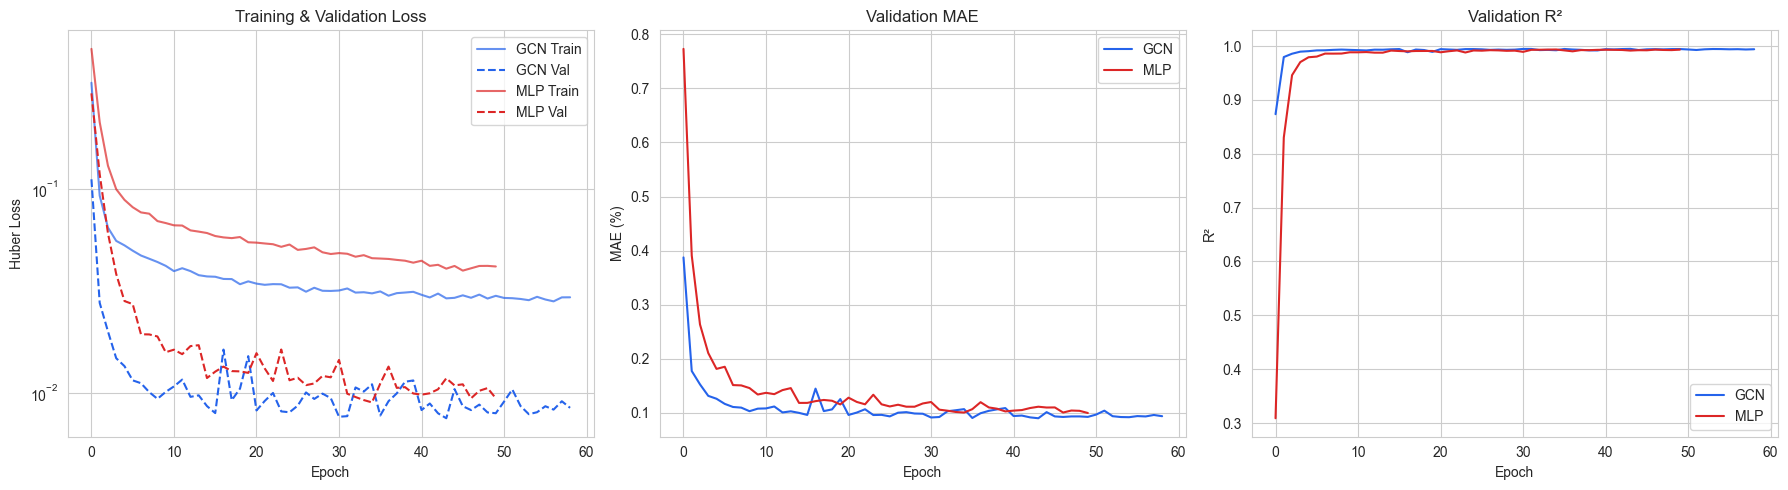

In [16]:
# === Training Curves ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'GCN': '#2563eb', 'MLP': '#dc2626'}

for name in ['GCN', 'MLP']:
    h = results[name]['history']

    axes[0].plot(h['train_loss'], label=f'{name} Train', color=colors[name], alpha=0.7)
    axes[0].plot(h['val_loss'], label=f'{name} Val', color=colors[name], linestyle='--')

    axes[1].plot(h['val_mae'], label=name, color=colors[name])
    axes[2].plot(h['val_r2'], label=name, color=colors[name])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (%)')
axes[1].set_title('Validation MAE')
axes[1].legend()

axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('R²')
axes[2].set_title('Validation R²')
axes[2].legend()

plt.tight_layout()
plt.show()

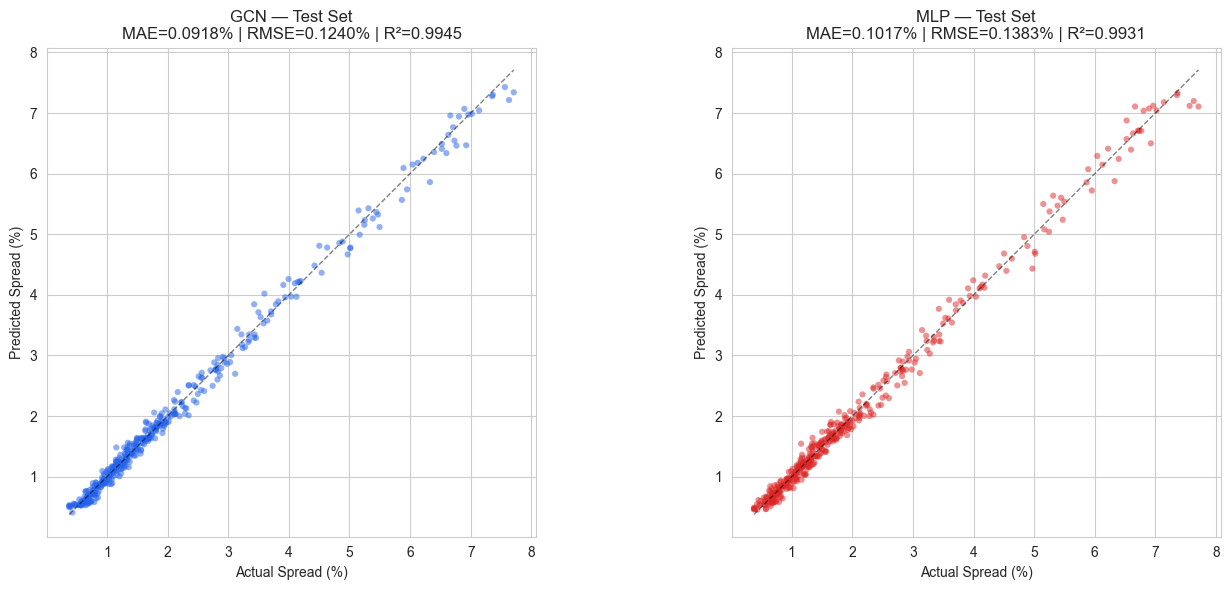

In [17]:
# === Predicted vs Actual Scatter ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, name in enumerate(['GCN', 'MLP']):
    ax = axes[i]
    tm = results[name]['test_metrics']
    ax.scatter(tm['actual'], tm['pred'], alpha=0.5, s=20, color=colors[name], edgecolors='none')

    # Perfect prediction line
    lims = [min(tm['actual'].min(), tm['pred'].min()),
            max(tm['actual'].max(), tm['pred'].max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Actual Spread (%)')
    ax.set_ylabel('Predicted Spread (%)')
    ax.set_title(f'{name} — Test Set\n'
                 f'MAE={tm["mae"]:.4f}% | RMSE={tm["rmse"]:.4f}% | R²={tm["r2"]:.4f}')
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

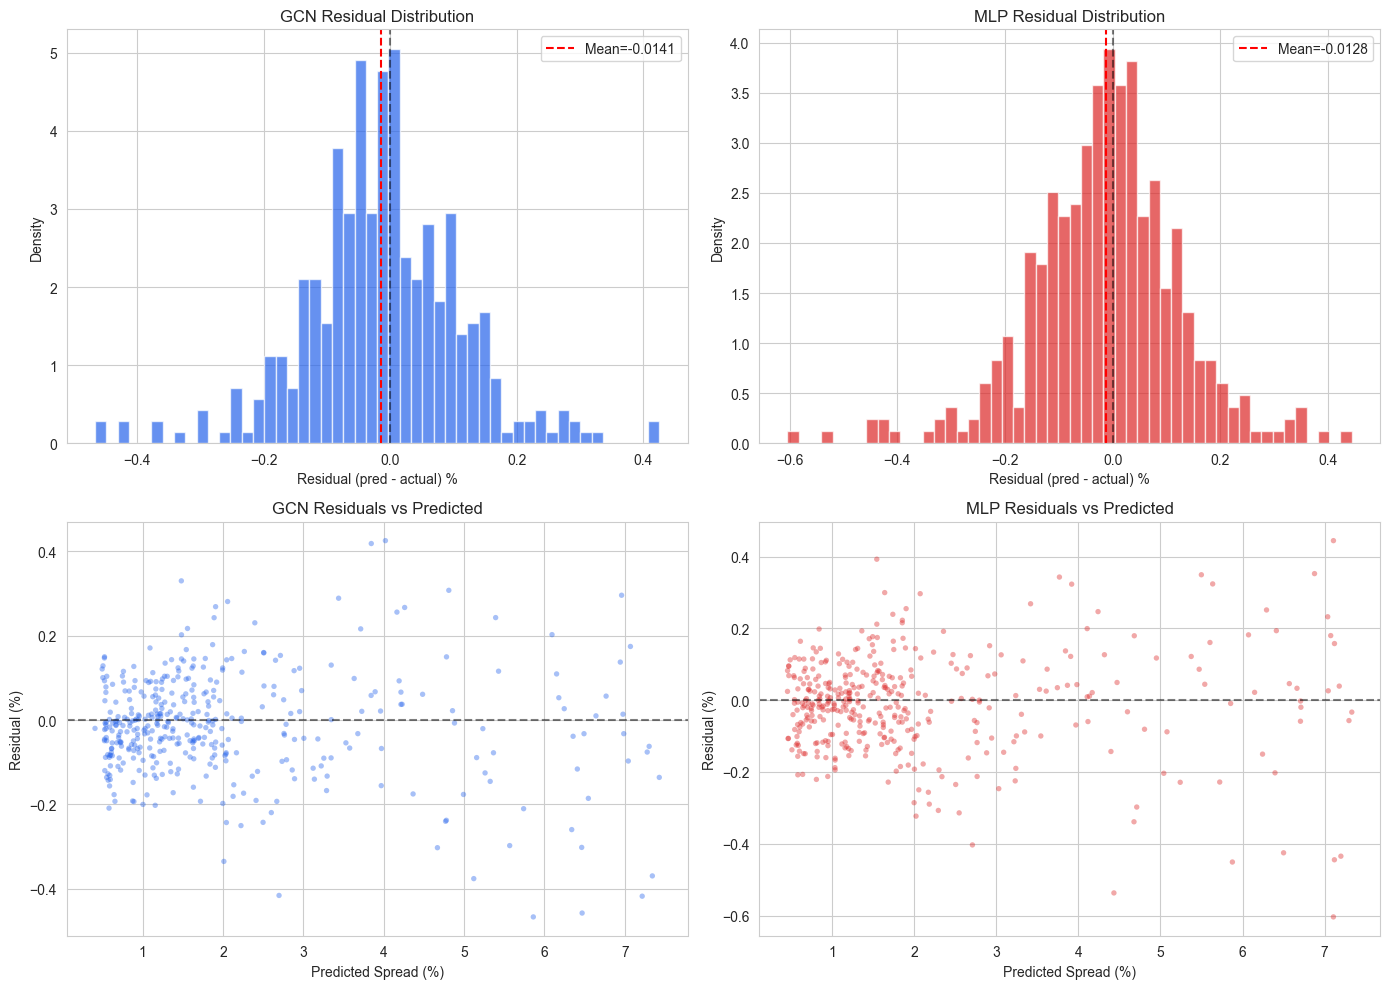

In [18]:
# === Residual Analysis ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, name in enumerate(['GCN', 'MLP']):
    tm = results[name]['test_metrics']
    residuals = tm['pred'] - tm['actual']

    # Residual distribution
    ax = axes[0, i]
    ax.hist(residuals, bins=50, color=colors[name], alpha=0.7, edgecolor='white', density=True)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(np.mean(residuals), color='red', linestyle='--',
               label=f'Mean={np.mean(residuals):.4f}')
    ax.set_xlabel('Residual (pred - actual) %')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} Residual Distribution')
    ax.legend()

    # Residuals vs predicted (check heteroscedasticity)
    ax = axes[1, i]
    ax.scatter(tm['pred'], residuals, alpha=0.4, s=15, color=colors[name], edgecolors='none')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Predicted Spread (%)')
    ax.set_ylabel('Residual (%)')
    ax.set_title(f'{name} Residuals vs Predicted')

plt.tight_layout()
plt.show()

In [19]:
# === Performance Breakdown by Rating Bucket ===

# Map test bond indices back to their ratings
gcn_tm = results['GCN']['test_metrics']
mlp_tm = results['MLP']['test_metrics']

gcn_ratings = [bond_ref.iloc[idx]['rating'] for idx in gcn_tm['bond_idx']]
mlp_ratings = [bond_ref.iloc[idx]['rating'] for idx in mlp_tm['bond_idx']]

# IG vs HY breakdown
gcn_rating_nums = np.array([bond_ref.iloc[idx]['rating_numeric'] for idx in gcn_tm['bond_idx']])
mlp_rating_nums = np.array([bond_ref.iloc[idx]['rating_numeric'] for idx in mlp_tm['bond_idx']])

print('\n' + '='*70)
print('PERFORMANCE COMPARISON: GCN vs MLP')
print('='*70)

print(f'\n{"Metric":<20} {"GCN":>12} {"MLP":>12} {"Δ (GCN-MLP)":>14}')
print('-'*60)

for metric_name, key in [('MAE (%)', 'mae'), ('RMSE (%)', 'rmse'), ('R²', 'r2')]:
    gcn_val = gcn_tm[key]
    mlp_val = mlp_tm[key]
    delta = gcn_val - mlp_val
    better = '←' if (delta < 0 and key != 'r2') or (delta > 0 and key == 'r2') else '→'
    print(f'{metric_name:<20} {gcn_val:>12.4f} {mlp_val:>12.4f} {delta:>+12.4f} {better}')

# By IG/HY
print(f'\n--- By Credit Quality (Test Set) ---')
for label, lo, hi in [('IG (AAA to BBB-)', 0, 9), ('HY (BB+ to B-)', 10, 15)]:
    gcn_mask = (gcn_rating_nums >= lo) & (gcn_rating_nums <= hi)
    mlp_mask = (mlp_rating_nums >= lo) & (mlp_rating_nums <= hi)

    if gcn_mask.sum() > 0 and mlp_mask.sum() > 0:
        gcn_mae = mean_absolute_error(gcn_tm['actual'][gcn_mask], gcn_tm['pred'][gcn_mask])
        mlp_mae = mean_absolute_error(mlp_tm['actual'][mlp_mask], mlp_tm['pred'][mlp_mask])
        gcn_r2 = r2_score(gcn_tm['actual'][gcn_mask], gcn_tm['pred'][gcn_mask])
        mlp_r2 = r2_score(mlp_tm['actual'][mlp_mask], mlp_tm['pred'][mlp_mask])
        print(f'\n  {label} (n={gcn_mask.sum()}):')
        print(f'    MAE — GCN: {gcn_mae:.4f}%  MLP: {mlp_mae:.4f}%')
        print(f'    R²  — GCN: {gcn_r2:.4f}   MLP: {mlp_r2:.4f}')


PERFORMANCE COMPARISON: GCN vs MLP

Metric                        GCN          MLP    Δ (GCN-MLP)
------------------------------------------------------------
MAE (%)                    0.0918       0.1017      -0.0100 ←
RMSE (%)                   0.1240       0.1383      -0.0143 ←
R²                         0.9945       0.9931      +0.0013 ←

--- By Credit Quality (Test Set) ---

  IG (AAA to BBB-) (n=300):
    MAE — GCN: 0.0767%  MLP: 0.0871%
    R²  — GCN: 0.9652   MLP: 0.9563

  HY (BB+ to B-) (n=100):
    MAE — GCN: 0.1370%  MLP: 0.1458%
    R²  — GCN: 0.9881   MLP: 0.9853


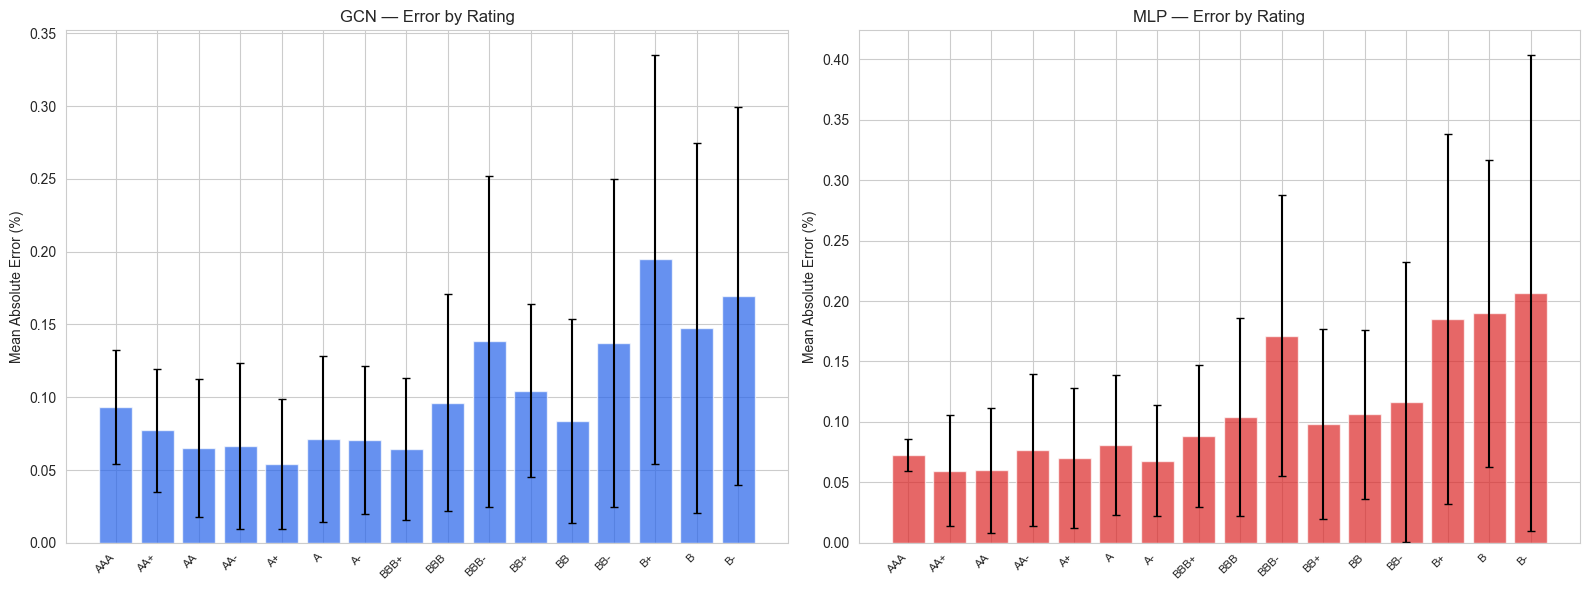

In [20]:
# === Error by Rating Notch ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, tm, rnums) in enumerate([
    ('GCN', gcn_tm, gcn_rating_nums),
    ('MLP', mlp_tm, mlp_rating_nums)
]):
    abs_errors = np.abs(tm['pred'] - tm['actual'])
    df_err = pd.DataFrame({'rating_num': rnums, 'abs_error': abs_errors})
    err_by_rating = df_err.groupby('rating_num')['abs_error'].agg(['mean', 'std']).reset_index()

    ax = axes[i]
    ax.bar(err_by_rating['rating_num'], err_by_rating['mean'],
           yerr=err_by_rating['std'], capsize=3, color=colors[name], alpha=0.7)
    ax.set_xticks(range(len(RATINGS)))
    ax.set_xticklabels(RATINGS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean Absolute Error (%)')
    ax.set_title(f'{name} — Error by Rating')

plt.tight_layout()
plt.show()

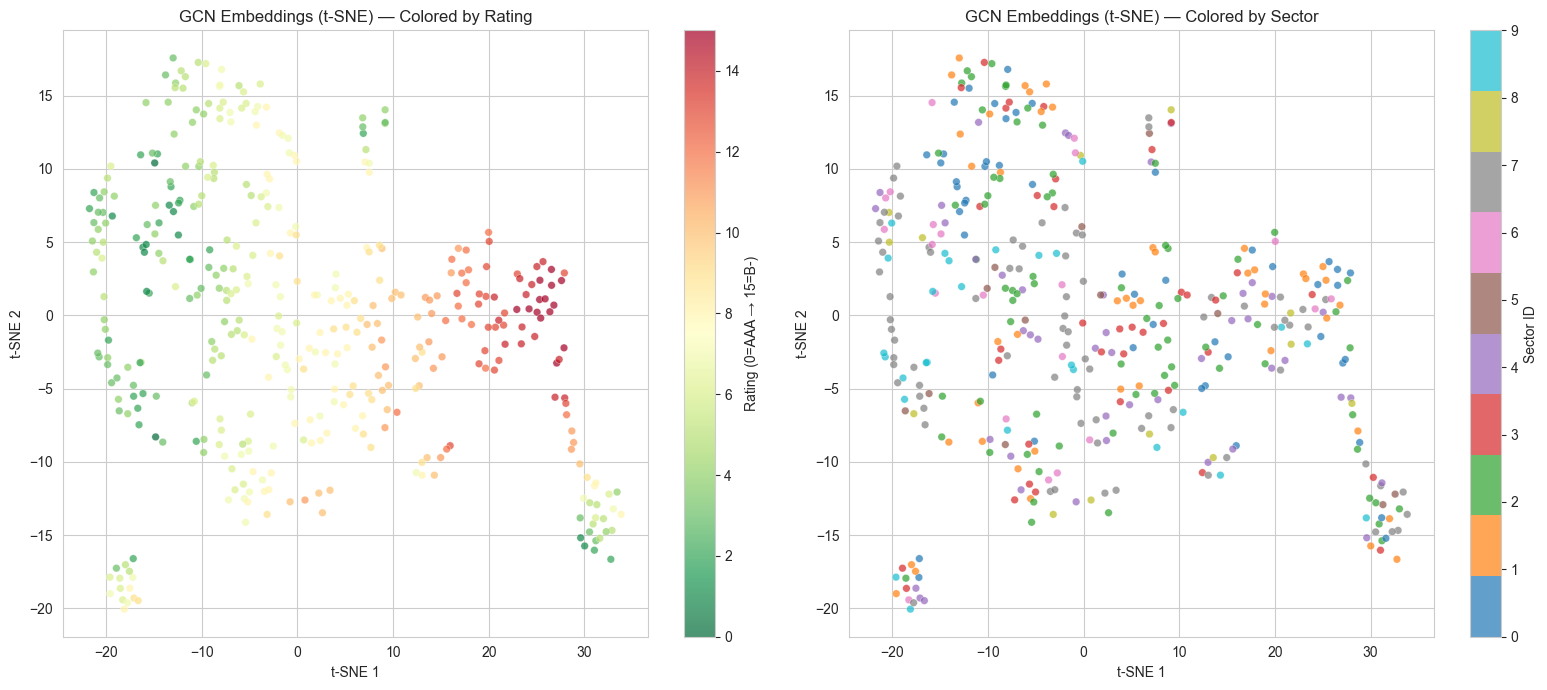

In [21]:
# === GNN Embedding Visualization (t-SNE) ===
from sklearn.manifold import TSNE

gcn_model = results['GCN']['model']
gcn_model.eval()

# Get node embeddings from the last GCN layer
with torch.no_grad():
    # Use mean node features across all test data
    node_feat, _ = create_graph_batch(X_test, idx_test, N_BONDS, N_FEATURES)
    node_feat = node_feat.to(device)
    ei = edge_index.to(device)
    ew = edge_weights.to(device)

    # Extract intermediate embeddings
    h = gcn_model.input_proj(node_feat)
    for i in range(gcn_model.n_gcn_layers):
        h_prev = h
        h = gcn_model.gcn_layers[i](h, ei, ew)
        h = gcn_model.norms[i](h)
        h = F.relu(h)
        h = h + h_prev

    embeddings = h.cpu().numpy()

# Only plot bonds that had some representation
active_mask = np.linalg.norm(embeddings, axis=1) > 0.01
emb_active = embeddings[active_mask]
ratings_active = bond_ref['rating_numeric'].values[active_mask]
sectors_active = bond_ref['sector_enc'].values[active_mask]

if len(emb_active) > 10:
    tsne = TSNE(n_components=2, perplexity=min(30, len(emb_active)-1),
                random_state=42, max_iter=1000)
    emb_2d = tsne.fit_transform(emb_active)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Color by rating
    scatter1 = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1],
                               c=ratings_active, cmap='RdYlGn_r',
                               alpha=0.7, s=30, edgecolors='white', linewidths=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Rating (0=AAA → 15=B-)')
    axes[0].set_title('GCN Embeddings (t-SNE) — Colored by Rating')
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')

    # Color by sector
    scatter2 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1],
                               c=sectors_active, cmap='tab10',
                               alpha=0.7, s=30, edgecolors='white', linewidths=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Sector ID')
    axes[1].set_title('GCN Embeddings (t-SNE) — Colored by Sector')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')

    plt.tight_layout()
    plt.show()
else:
    print('Not enough active bonds for t-SNE visualization.')

In [22]:
# === Summary Statistics Table ===
print('\n' + '='*70)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*70)

summary_data = []
for name in ['GCN', 'MLP']:
    tm = results[name]['test_metrics']
    n_params = sum(p.numel() for p in results[name]['model'].parameters())
    summary_data.append({
        'Model': name,
        'Parameters': f'{n_params:,}',
        'Test MAE (%)': f'{tm["mae"]:.4f}',
        'Test RMSE (%)': f'{tm["rmse"]:.4f}',
        'Test R²': f'{tm["r2"]:.4f}',
        'Uses Graph': 'Yes' if name == 'GCN' else 'No',
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


FINAL MODEL COMPARISON SUMMARY
Model Parameters Test MAE (%) Test RMSE (%) Test R² Uses Graph
  GCN     11,713       0.0918        0.1240  0.9945        Yes
  MLP      7,553       0.1017        0.1383  0.9931         No


<a id='section-7'></a>
## 7. Future Research Directions

### Architecture Improvements

1. **Graph Attention Networks (GAT)**: Replace GCN's fixed normalization with learned attention
   weights, allowing the model to dynamically decide which neighbors are most informative.
   Particularly useful when some neighbors have stale prices and should be down-weighted.

2. **Temporal Graph Networks**: Incorporate time-aware message-passing (e.g., TGN, TGAT)
   where edges carry temporal information and the aggregation decays with staleness.
   This is the natural extension for irregularly-spaced TRACE data.

3. **Heterogeneous Graphs**: Model multiple node types (bonds, issuers, sectors) and
   multiple edge types (same-issuer, same-rating, same-sector) in a heterogeneous GNN
   framework (R-GCN or HGT).

4. **Probabilistic Output**: Replace point estimates with distributional predictions
   (e.g., Gaussian output layer, quantile regression, or mixture density networks)
   to produce prediction intervals — critical for trading applications.

### Data & Feature Engineering

5. **Real TRACE data**: Replace synthetics with actual FINRA TRACE disseminated data.
   Key challenges: handling cancellations/corrections, agency vs. principal trades,
   capped trade sizes ($5MM+ reported as 5MM+), and weekday/month-end effects.

6. **Market-level features**: Add VIX, CDX index level, treasury curve slope,
   Fed Funds rate, and recent new-issue supply as global conditioning variables.

7. **CDS-Bond Basis**: For issuers with liquid CDS, incorporate the CDS spread
   as an additional node feature to anchor the model with a market-implied credit signal.

8. **Dealer marks / Axes**: Incorporate pre-trade dealer indications (runs, axes)
   as auxiliary features, particularly from platforms like MarketAxess, Tradeweb, or Bloomberg.

### Training & Evaluation

9. **Dynamic graph updates**: Reconstruct the k-NN graph periodically (e.g., monthly)
   to capture bonds rolling down the maturity curve and rating migrations.

10. **Online learning**: Implement incremental graph updates as new trades arrive,
    rather than retraining on the full history.

11. **Cross-validation with embargo**: Use purged k-fold CV with temporal gaps
    between train and test to prevent information leakage.

12. **Loss function design**: Experiment with asymmetric losses (overpricing
    vs. underpricing have different economic consequences) and spread-weighted
    losses (errors on tight IG spreads vs. wide HY spreads).

### Production Considerations

13. **Inference latency**: For live pricing, pre-compute graph structure and
    only update node features on new trades. Target sub-10ms inference.

14. **Model monitoring**: Track prediction drift, calibration degradation,
    and graph topology changes over time.

15. **Explainability**: Use GNN explainability methods (GNNExplainer, PGExplainer)
    to identify which neighbors and features drive each prediction — essential for
    regulatory and risk management purposes in fixed income markets.